# Mixture of Mixture of Gaussians Example

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib
import scipy
from copy import copy
from sklearn.preprocessing import KernelCenterer

#import code to generate data and do clustNP
from sample_distributions import pair_sample_mixture_of_GMs
from NDIGO import gauss_kernal_mat, proj_simplex

# Set Parameters

In [2]:
np.random.seed(123)

n = 150 # number of total paired samples
nhold = 100
ntest = 100
M = 2   # true number of mixture components for our KDE
Mprime = 1
d = 1   # ambient dimension 

#w_outer = np.random.rand(M,) # true KDE mixture proportions
w_outer = np.ones((M,))
w_outer *= 1/np.sum(w_outer)
w_inner = np.ones((M,1))
#mus = 2*np.random.randn(1, d, M) # true means for each mixture distribution
mus = np.ones((1, d, M))
#mus[0,0,0] = -2
sigmas = np.ones((1,d,d,M))


noise_sd = .1

# Generate Data

In [3]:
X, component_ids, pair_ids = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=n)
Xh, cid_h, pid_h = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=nhold)
Xte, cid_te, pid_te = pair_sample_mixture_of_GMs(mus, sigmas, w_outer, w_inner, n=ntest)
w_outer

X = np.random.uniform(-2,2,(2*n,1)) #just reuse component ids since all are coming from the same distribution

### Plot Pairs as endpoints of line segments

Text(0.5, 0, 'x')

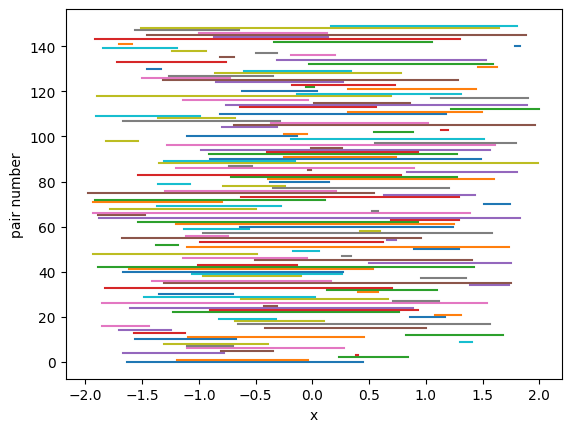

In [4]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Generate func vals

# Linear

In [5]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = 4*(X[component_ids==0] > 0) # x + 1
Y[(component_ids==1)] = 4*(X[component_ids==1] < 0) #3*x+ 2 #4
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

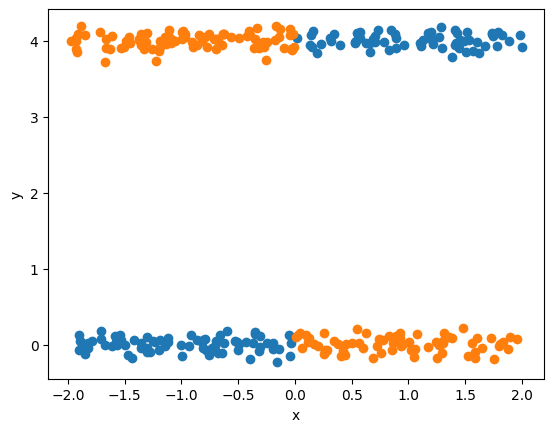

In [6]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
plt.xlabel("x")
plt.ylabel("y")
plt.rc('axes', labelsize=20)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=8)    # fontsize of the tick labels
plt.rc('ytick', labelsize=8)    # fontsize of the tick labels
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

Text(0.5, 0, 'x')

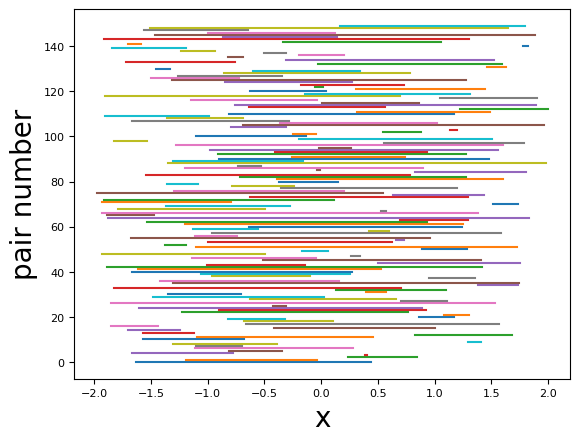

In [7]:
for i in range(n):
    pair = X[pair_ids==i]
    plt.plot(pair, [i,i])
plt.ylabel("pair number")
plt.xlabel("x")

# Nonlinear

In [8]:
Y = np.ndarray((2*n,1))
Y[(component_ids==0)] = 4*(X[component_ids==0] > 0) # x + 1
Y[(component_ids==1)] = 4*(X[component_ids==1] < 0) #3*x+ 2 #4
Ytrue = copy(Y)
Y = Y + np.random.normal(0, noise_sd, Y.shape)

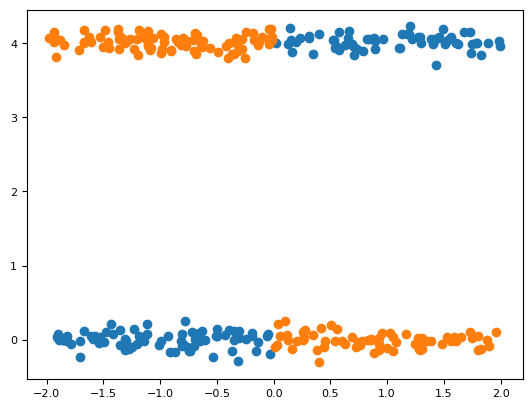

In [9]:
plt.scatter(X[component_ids==0],Y[component_ids==0])
plt.scatter(X[component_ids==1],Y[component_ids==1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

# EM

In [10]:
def lstsq_nesterov(X, Y, alpha0, maxiter=2000):
    Y = Y.flatten()
    ss = 1/np.linalg.norm(X, ord='fro')**2
    alpha = alpha0
    z = alpha0
    gamma = 1
    XtX = X.T@X
    XtY = X.T@Y
    for i in range(maxiter):
        alpha_old = alpha
        alpha = z + ss*(XtY-XtX@z)
        gamma = (np.sqrt(4*gamma**2 + gamma**4) - gamma**2)*0.5
        beta = gamma*(1-1/gamma)
        z = alpha + beta*(alpha - alpha_old)
    return alpha  

In [11]:
# # define model
# model = MyNN()

# for em_iter in range(T):

#     # E-step
#     gamma = compute_responsibilities(...)

#     # M-step (train NN with weights gamma)
#     for step in range(k):
#         preds = model(x)
#         loss = weighted_loss(preds, y, gamma)
#         loss.backward()
#         optimizer.step()


In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

# -------------------------
# Simple feedforward network
# -------------------------
class Net(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


# -------------------------
# Weighted loss
# -------------------------
def weighted_mse(pred, target, weights):
    # pred: (n, d)
    # target: (n, d)
    # weights: (n,)
    loss = (pred - target)**2
    loss = loss.mean(dim=1)        # per-sample loss (n,)
    return (weights * loss).sum() / weights.sum()


# -------------------------
# E-step (example placeholder)
# -------------------------


def compute_responsibilities(x, Y, w, models, noise_sd):
    x = torch.tensor(x, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)
    
    n2 = x.shape[0] # total data points = 2*number pairs n
    M = len(models)
    
    assert n2 % 2 == 0, "n must be even for pairing"

    w_tensor = torch.tensor(w, dtype=torch.float32)

    log_probs = []

    # --- compute per-model log probs ---
    for im in range(M):
        mu = models[im](x)
        Delta = (Y - mu) ** 2
        
        log_likelihood = -Delta / (2 * noise_sd**2)
        log_prior = torch.log(w_tensor[im])
        
        log_probs.append(log_likelihood.squeeze() + log_prior)

    # shape: (n2, M)
    log_probs = torch.stack(log_probs, dim=1)

    # group the pairs
    log_probs_pairs = log_probs.view(n2 // 2, 2, M)

    # sum within each pair (correct probabilistically)
    log_probs_pairwise = log_probs_pairs.sum(dim=1)  # (n2/2, M)

    # compute responsibilities at pair level
    gamma_pairwise = torch.softmax(log_probs_pairwise, dim=1)  # (n2/2, M)

    # expand back so each pair shares gamma
    gamma = gamma_pairwise.repeat_interleave(2, dim=0)  # (n2, M)

    return gamma

kern_width = 0.8

K = gauss_kernal_mat(X,X,sigma=kern_width)
# transformer = KernelCentere
#r().fit(K)
# K = transformer.transform(K)
w, A = scipy.sparse.linalg.eigs(K, k=M)
w = np.real(w)
A = np.real(A)
w = w/np.sum(w)
maxiter = 30

R = np.zeros((n,M))


# -------------------------
# Main EM loop
# -------------------------

def EM_train(x, y, M, em_iters=10, inner_steps=10):
    n, d = x.shape
    x = torch.tensor(x, dtype=torch.float32)
    y = torch.tensor(y, dtype=torch.float32)

    # initialize models + optimizers
    models = [Net(d, 32, y.shape[1]) for _ in range(M)]
    opts = [optim.Adam(m.parameters(), lr=1e-3) for m in models]

    for em_iter in range(em_iters):

        # -----------------
        # E-step
        # -----------------
        gamma = compute_responsibilities(x, y, w, models, noise_sd)  # (n, M)
    

        # -----------------
        # M-step
        # -----------------
        for m in range(M):
            model = models[m]
            opt = opts[m]

            weights = gamma[:, m].detach()  # (n,)

            for _ in range(inner_steps):
                opt.zero_grad()

                pred = model(x)
                loss = weighted_mse(pred, y, weights)

                loss.backward()
                opt.step()

        # print(f"EM iter {em_iter} done")

    return models

In [13]:
X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

models = EM_train(X_tensor, Y_tensor, M=2, em_iters=100, inner_steps=100)

C:\Users\jj\AppData\Local\Temp\ipykernel_32708\4049316002.py:99: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_32708\4049316002.py:100: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_32708\4049316002.py:39: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x, dtype=torch.float32)
C:\Users\jj\AppData\Local\Temp\ipykernel_32708\4049316002.py:40: UserWarning: To copy c

In [14]:
# kern_width = 0.8

# K = gauss_kernal_mat(X,X,sigma=kern_width)
# # transformer = KernelCentere
# #r().fit(K)
# # K = transformer.transform(K)
# w, A = scipy.sparse.linalg.eigs(K, k=M)
# w = np.real(w)
# A = np.real(A)
# w = w/np.sum(w)
# maxiter = 30

# R = np.zeros((n,M))

# for i in range(maxiter):
#     print(i)
#     # E-step
#     Delta = (Y - K@A)**2 #square loss for each observation for each component
#     #Delta = np.exp((1/(2*noise_sd**2))*(Delta[0::2] + Delta[1::2]))*w #add pairs and scale by mixing weights
#     Delta = (np.exp((1/(2*noise_sd**2))) + np.exp((Delta[0::2] + Delta[1::2])))*w
#     R =  ( Delta.T * (1/np.sum(Delta, axis=1)) ).T
    
#     # M-step
#     w = np.sum(R,axis=0) / n
#     for j in range(M):
#         Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         A[:,j] = lstsq_nesterov((K.T*Rm).T, (Y.T*Rm).T, A[:,j])
#         #A[:,j] = np.linalg.lstsq((K.T*Rm).T, (Y.T*Rm).T, rcond=None)[0].flatten()
#         print("final: ", np.linalg.norm((Y.T*Rm).T.flatten() - (K.T*Rm).T@A[:,j]))


In [15]:
print(R)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

In [16]:
Rprime = copy(R)
Rprime[R<0.01] = 0
Rprime[R>0.99] = 1
print(Rprime)

[[0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 [0. 0.]
 

# Check out the results

In [17]:
# Y_hat = np.zeros((2*n,M))
# for j in range(M):
#         #Rm = np.repeat(R[:,j]**0.5,2,axis=0)
#         #Y_hat[:,j] = (K.T*Rm).T@A[:,j]
#         Y_hat[:,j] = K@A[:,j]

[ 6.69519305e-02  6.44094348e-02  6.18650317e-02  5.93244433e-02
  5.67857623e-02  5.46075702e-02  5.27307391e-02  5.08634448e-02
  4.89293933e-02  4.69915271e-02  4.50441241e-02  4.31062579e-02
  4.11626697e-02  3.92209888e-02  3.72735858e-02  3.53376269e-02
  3.33959460e-02  3.14103961e-02  2.93924212e-02  2.73839831e-02
  2.53641009e-02  2.33537555e-02  2.13415027e-02  1.93254352e-02
  1.73074603e-02  1.52952075e-02  1.32829547e-02  1.12649798e-02
  9.25272703e-03  7.23856688e-03  5.22440672e-03  3.91596556e-03
  3.48109007e-03  3.03858519e-03  2.60752439e-03  2.16692686e-03
  1.73205137e-03  1.28954649e-03  8.56578350e-04  4.29332256e-04
  4.14073467e-04  3.93092632e-04  3.75926495e-04  3.60667706e-04
  3.35872173e-04  3.20613384e-04  2.99632549e-04  2.82466412e-04
  2.61485577e-04  2.42412090e-04  2.23338604e-04  2.06172466e-04
  1.87098980e-04  1.69932842e-04  1.52766705e-04  1.31785870e-04
  1.08897686e-04  9.17315483e-05  7.26580620e-05  5.16772270e-05
  3.45110893e-05  1.92523

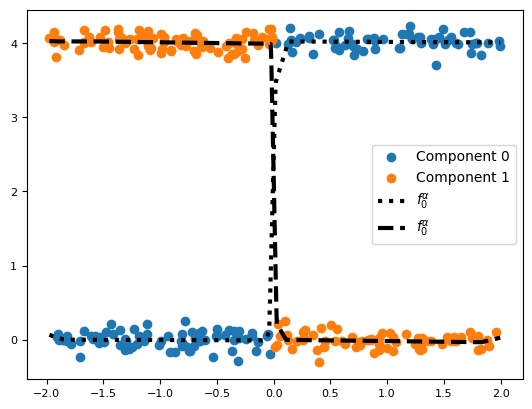

In [18]:
plt.scatter(X[component_ids==0],Y[component_ids==0], label="Component 0")
plt.scatter(X[component_ids==1],Y[component_ids==1], label="Component 1")

xx = np.reshape(np.linspace(np.min(X),np.max(X),1000), (1000,1))
xx_tensor = torch.tensor(xx, dtype=torch.float32)
# Ktest = gauss_kernal_mat(xx,X,sigma=kern_width)
# Yhat = Ktest@A
Yhat_tens = torch.zeros((xx_tensor.shape[0], M), dtype=torch.float32)  # tensor instead of np.zeros

for m in range(M):
    # forward pass
    Yhat_tens[:, m] = models[m](xx_tensor).squeeze()

Yhat = Yhat_tens.detach().numpy()

print(Yhat[:,0])
print(Yhat[:,1])
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_0^\alpha$")

Rdouble = np.repeat(R,2,axis=0)
correct_assignments = max(sum(component_ids==np.argmax(Rdouble,axis=1) ), 
                          sum((1-component_ids)==np.argmax(Rdouble,axis=1)) 
                         ) / (2*n)
print(f"Prop Correct Mixture Assignment = {correct_assignments}")

plt.rcParams.update({'font.size': 10})
plt.legend()

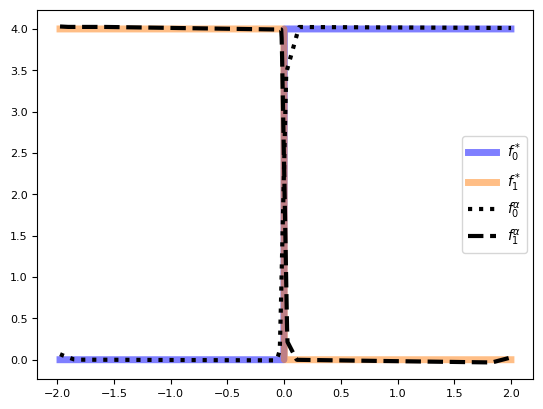

In [19]:
plt.plot(xx, 4*(xx>0), 'b', linewidth=5, label="$f_0^*$", alpha=0.5)
plt.plot(xx, 4*(xx<0), 'tab:orange', linewidth=5, label="$f_1^*$", alpha=0.5)
plt.plot(xx, Yhat[:,0], 'k:', linewidth=3, label=r"$f_0^\alpha$")
plt.plot(xx, Yhat[:,1], 'k--', linewidth=3, label=r"$f_1^\alpha$")
plt.rcParams.update({'font.size': 10})
plt.legend()


In [20]:
Rdouble = np.repeat(R,2,axis=0)
plt.scatter(X[np.argmax(Rdouble,axis=1)==0],Yhat[np.argmax(Rdouble,axis=1)==0,0])
plt.scatter(X[np.argmax(Rdouble,axis=1)==1],Yhat[np.argmax(Rdouble,axis=1)==1,1])
idx = np.argsort(X.flatten())
X_sorted = X.flatten()[idx]
Y_sorted = Y.flatten()[idx]
#plt.plot(X_sorted.flatten(), Y_sorted.flatten(), color='r')

IndexError: boolean index did not match indexed array along axis 0; size of axis is 1000 but size of corresponding boolean axis is 300

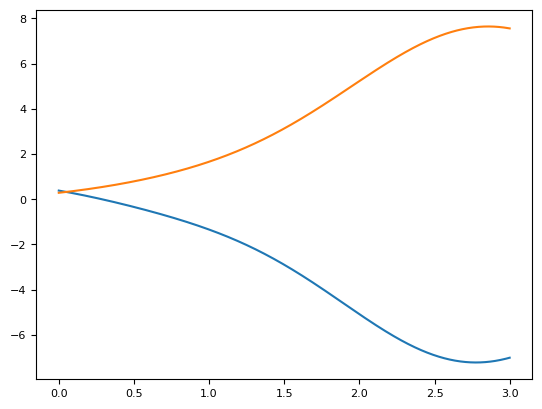

In [ ]:
xx = np.reshape(np.linspace(0,3,1000), (1000,1))
Ktest = gauss_kernal_mat(xx,X,sigma=0.95)
Yhat = Ktest@A
plt.plot(xx, Yhat[:,0])
plt.plot(xx, Yhat[:,1])